
<span style="color:	#008080 ; font-size:20px">Mihaela Strimbeschi</span>

<div style="text-align:center; color:#008080; font-size:20px">
  <h3>Amazon:The Last-Mile Challenges</h3>
</div>

---
<div style="text-align:left; color:	#008080 ; font-size:15px">
<h3>Introduction</h3>
</div>

This analysis examines Amazon delivery data, including order details, delivery agents' demographics and ratings, locations, environmental conditions (weather, traffic), vehicle types, and delivery times. The goal is to assess key factors affecting delivery efficiency and identify opportunities for optimization.

---

<div style="text-align:left; color:	#008080 ; font-size:15px">
<h3>Objective</h3>
</div>

The objective of this analysis is to identify the factors affecting delivery efficiency and propose solutions for optimization. The analysis is structured around several categories: agent characteristics, external conditions (traffic, weather), and delivery area.

<div style="text-align:left; color:	#008080 ; font-size:15px">
<h3>Questions</h3>
</div>

To achieve this objective, I would like to answer the following questions to identify key factors influencing delivery performance and potential areas for optimization.

---

   1. What is the relationship between the agent’s age and delivery time?
   2. How does the agent’s rating influence delivery time?
   3. Which agents deliver the fastest, and what are their characteristics?
   4. Are there performance differences between agents with similar ratings but different ages?
   5. Which time intervals have the highest average delivery times?
   6. On which days of the week are delivery times higher?
   7. How does delivery performance vary across different geographic zones?
   8. How do different weather conditions impact delivery times?
   9. Which traffic conditions lead to the highest delivery times?

---



<div style="text-align:left; color:	#008080 ; font-size:15px">
<h3>About the Dataset</h3>
</div>

This Amazon Delivery Dataset provides a comprehensive view of the company's last-mile logistics operations. It includes data on over 43,632 deliveries across multiple cities, with detailed information on order details, delivery agents, weather and traffic conditions, and delivery performance metrics. The dataset enables researchers and analysts to uncover insights into factors influencing delivery efficiency, identify areas for optimization, and explore the impact of various variables on the overall customer experience.

---

[Link data Kaggle](https://www.kaggle.com/datasets/sujalsuthar/amazon-delivery-dataset/data)

---

**Column Descriptors**

1. ***Order_ID*** – Unique identifier for each order
2. ***Agent_Age*** – Age of the delivery agent
3. ***Agent_Rating*** – Rating or performance score of the delivery agent
4. ***Store_Latitude*** – Geographic coordinates of the store where the order was placed
5. ***Store_Longitude*** – Geographic coordinates of the store where the order was placed
6. ***Drop_Latitude*** – Geographic coordinates of the delivery location
7. ***Drop_Longitude*** – Geographic coordinates of the delivery location
8. ***Order_Date*** – Date when the order was placed
9. ***Order_Time*** – Time when the order was placed
10. ***Pickup_Time*** – Time when the order was picked up for delivery
11. ***Weather*** – Weather conditions during the delivery (e.g., sunny, rainy, snowy)
12. ***Traffic*** – Traffic conditions during the delivery (e.g., low, medium, jam)
13. ***Vehicle*** – Type of vehicle used for the delivery (e.g., van, motorcycle, bicycle, scooter)
14. ***Area*** – Area where the delivery took place (Urban, Metropolitan, etc.)
15. ***Delivery_Time*** – Time taken to complete the delivery
16. ***Category*** – Product category of the ordered item (e.g., electronics, apparel, groceries)

---

### Step 1: Importing Necessary Libraries

In this first step, I will import the neccesary libaries for analysis:

In [4]:
import pandas as pd                                                   # pandas: data manipulation and analysis
import numpy as np                                                    # numpy: numerical computations
import matplotlib.pyplot as plt                                       # matplotlib.pyplot: static/interactive plots
import seaborn as sns                                                 # seaborn: statistical data visualization
from datetime import datetime                                         # datetime: work with dates and times

### Step 2: Loading and Inspecting the Data

In [6]:
#import the data

df = pd.read_csv('amazon_delivery_data.csv')

After importing and loading the dataset, I will inspect the data to understand the columns, data types, and identify any issues such us missing values, and incorrect data types.

1. First, I will inspect the first five rows of the ***amazon_delivery_data*** dataset using the **.head()** method to understand its structure.


_By default, the **.head()** method displays the first 5 rows, the number of rows can be changed by passing a specific number inside the method._

In [8]:
# display the first few rows of the dataset

df.head()

,Order_ID,Agent_Age,Agent_Rating,Store_Latitude,Store_Longitude,Drop_Latitude,Drop_Longitude,Order_Date,Order_Time,Pickup_Time,Weather,Traffic,Vehicle,Area,Delivery_Time,Category
0,ialx566343618,37,4.9,22.745049,75.892471,22.765049,75.912471,2022-03-19,11:30:00,11:45:00,Sunny,High,motorcycle,Urban,120,Clothing
1,akqg208421122,34,4.5,12.913041,77.683237,13.043041,77.813237,2022-03-25,19:45:00,19:50:00,Stormy,Jam,scooter,Metropolitian,165,Electronics
2,njpu434582536,23,4.4,12.914264,77.678400,12.924264,77.688400,2022-03-19,08:30:00,08:45:00,Sandstorms,Low,motorcycle,Urban,130,Sports
3,rjto796129700,38,4.7,11.003669,76.976494,11.053669,77.026494,2022-04-05,18:00:00,18:10:00,Sunny,Medium,motorcycle,Metropolitian,105,Cosmetics
4,zguw716275638,32,4.6,12.972793,80.249982,13.012793,80.289982,2022-03-26,13:30:00,13:45:00,Cloudy,High,scooter,Metropolitian,150,Toys


2. Next, to gather more information about the data I will use the **.info()** method. 

In [10]:
#display information about the dataset

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 43739 entries, 0 to 43738
Data columns (total 16 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Order_ID         43739 non-null  object 
 1   Agent_Age        43739 non-null  int64  
 2   Agent_Rating     43685 non-null  float64
 3   Store_Latitude   43739 non-null  float64
 4   Store_Longitude  43739 non-null  float64
 5   Drop_Latitude    43739 non-null  float64
 6   Drop_Longitude   43739 non-null  float64
 7   Order_Date       43739 non-null  object 
 8   Order_Time       43739 non-null  object 
 9   Pickup_Time      43739 non-null  object 
 10  Weather          43648 non-null  object 
 11  Traffic          43739 non-null  object 
 12  Vehicle          43739 non-null  object 
 13  Area             43739 non-null  object 
 14  Delivery_Time    43739 non-null  int64  
 15  Category         43739 non-null  object 
dtypes: float64(5), int64(2), object(9)
memory usage: 5.3+ MB


*Result Explained*

The result tells us there are 43739 entries and 16 columns(for this we can use and .shape method), the number of non-null values in each column and the data types of each column.

In [12]:
df.shape

(43739, 16)

In [13]:
#summary statistics

df.describe()

,Agent_Age,Agent_Rating,Store_Latitude,Store_Longitude,Drop_Latitude,Drop_Longitude,Delivery_Time
count,43739.000000,43685.000000,43739.000000,43739.000000,43739.000000,43739.000000,43739.000000
mean,29.567137,4.633780,17.210960,70.661177,17.459031,70.821842,124.905645
std,5.815155,0.334716,7.764225,21.475005,7.342950,21.153148,51.915451
min,15.000000,1.000000,-30.902872,-88.366217,0.010000,0.010000,10.000000
25%,25.000000,4.500000,12.933298,73.170283,12.985996,73.280000,90.000000
50%,30.000000,4.700000,18.551440,75.898497,18.633626,76.002574,125.000000
75%,35.000000,4.900000,22.732225,78.045359,22.785049,78.104095,160.000000
max,50.000000,6.000000,30.914057,88.433452,31.054057,88.563452,270.000000


3. To see how many missing values there are, I'll check and count them using the **.isnull().sum()**

In [15]:
# check for missing values

missing_values = df.isnull().sum()
missing_values

Order_ID            0
Agent_Age           0
Agent_Rating       54
Store_Latitude      0
Store_Longitude     0
Drop_Latitude       0
Drop_Longitude      0
Order_Date          0
Order_Time          0
Pickup_Time         0
Weather            91
Traffic             0
Vehicle             0
Area                0
Delivery_Time       0
Category            0
dtype: int64

_Result Explained_

As we can see, there are some missing values in the following columns:

***Agent_Rating*** – 54 missing values

***Weather*** – 91 missing values

In [17]:
# filter columns with missing values

missing_values = missing_values[missing_values > 0].reset_index()
missing_values.columns = ['Agent_Rating', 'Weather']

# display missing values
missing_values

,Agent_Rating,Weather
0,Agent_Rating,54
1,Weather,91


### Step 3: Data Cleaning


Before making any changes to the original data, I will create a copy of the dataset. This ensures that I can always revert to the original if needed.

In [19]:
df_cleaned = df.copy() 

In [20]:
#check dataset copy

df_cleaned.head()

,Order_ID,Agent_Age,Agent_Rating,Store_Latitude,Store_Longitude,Drop_Latitude,Drop_Longitude,Order_Date,Order_Time,Pickup_Time,Weather,Traffic,Vehicle,Area,Delivery_Time,Category
0,ialx566343618,37,4.9,22.745049,75.892471,22.765049,75.912471,2022-03-19,11:30:00,11:45:00,Sunny,High,motorcycle,Urban,120,Clothing
1,akqg208421122,34,4.5,12.913041,77.683237,13.043041,77.813237,2022-03-25,19:45:00,19:50:00,Stormy,Jam,scooter,Metropolitian,165,Electronics
2,njpu434582536,23,4.4,12.914264,77.678400,12.924264,77.688400,2022-03-19,08:30:00,08:45:00,Sandstorms,Low,motorcycle,Urban,130,Sports
3,rjto796129700,38,4.7,11.003669,76.976494,11.053669,77.026494,2022-04-05,18:00:00,18:10:00,Sunny,Medium,motorcycle,Metropolitian,105,Cosmetics
4,zguw716275638,32,4.6,12.972793,80.249982,13.012793,80.289982,2022-03-26,13:30:00,13:45:00,Cloudy,High,scooter,Metropolitian,150,Toys


**3.1 Handling missing values**

Because the **Agent_Rating** column is important for analyzing agent performance I will fill in missing values with the _mean_ of the existing ratings to maintain  data consistency and minimize bias.

In [23]:
# handling missing values with mean

agent_rating_mean = df_cleaned['Agent_Rating'].mean()
df_cleaned['Agent_Rating'] = df_cleaned['Agent_Rating'].fillna(agent_rating_mean)

For the **Weather** column I will use the _mode_ (most common weather condition) to fill in missing values.

In [25]:
#handling missing values with mode

weather_mode = df_cleaned['Weather'].mode()[0]
df_cleaned['Weather'].fillna(weather_mode, inplace=True)

In [26]:
# check data for null values

df_cleaned.isna().sum()

Order_ID           0
Agent_Age          0
Agent_Rating       0
Store_Latitude     0
Store_Longitude    0
Drop_Latitude      0
Drop_Longitude     0
Order_Date         0
Order_Time         0
Pickup_Time        0
Weather            0
Traffic            0
Vehicle            0
Area               0
Delivery_Time      0
Category           0
dtype: int64

**3.2 Check for duplicates**

In [28]:
# check the number of duplicates before removing

df_cleaned.duplicated().sum()


0

No duplicates were found in the DataFrame

**3.3 Data type correction**

In [31]:
#check the data types of each column

df_cleaned.dtypes

Order_ID            object
Agent_Age            int64
Agent_Rating       float64
Store_Latitude     float64
Store_Longitude    float64
Drop_Latitude      float64
Drop_Longitude     float64
Order_Date          object
Order_Time          object
Pickup_Time         object
Weather             object
Traffic             object
Vehicle             object
Area                object
Delivery_Time        int64
Category            object
dtype: object

In [32]:
df_cleaned[['Order_Date','Order_Time','Pickup_Time']].dtypes

Order_Date     object
Order_Time     object
Pickup_Time    object
dtype: object

Because these columns ['Order_Date','Order_Time','Pickup_Time'] are stored as a string(object), I need to convert them to **datetime** , but before doing this I need to make sure there can be converted without problems, so I will investigate each column 

The next step involves extracting the year, month, day, and weekday from **'Order_Date,'** and deriving **'Order_Hour'** and **'Pickup_Hour'** from **'Order_Time'** and **'Pickup_Time**.

In [35]:
# convert Order_Date to datetime format and extract components
df_cleaned['Order_Date'] = pd.to_datetime(df_cleaned['Order_Date'])
df_cleaned['Year'] = df_cleaned['Order_Date'].dt.year
df_cleaned['Month'] = df_cleaned['Order_Date'].dt.month
df_cleaned['Day'] = df_cleaned['Order_Date'].dt.day
df_cleaned['Weekday'] = df_cleaned['Order_Date'].dt.weekday

# check for invalid values in Order_Time before conversion
df_cleaned['Order_Time'].isna().sum()
# display the first 10 values
df_cleaned['Order_Time'].head(10)  

# convert Order_Time and Pickup_Time to datetime 
df_cleaned['Order_Time'] = pd.to_datetime(df_cleaned['Order_Time'], format='%H:%M:%S', errors='coerce')
df_cleaned['Pickup_Time'] = pd.to_datetime(df_cleaned['Pickup_Time'], format='%H:%M:%S', errors='coerce')

# extract Order_Hour and Pickup_Hour
df_cleaned['Order_Hour'] = df_cleaned['Order_Time'].dt.hour
df_cleaned['Pickup_Hour'] = df_cleaned['Pickup_Time'].dt.hour

# handle missing values in Order_Hour 
df_cleaned['Order_Hour'] = df_cleaned['Order_Hour'].fillna(df_cleaned['Order_Hour'].median())  
df_cleaned['Pickup_Hour'] = df_cleaned['Pickup_Hour'].fillna(df_cleaned['Pickup_Hour'].median())

# verify if there are still missing values
df_cleaned['Order_Hour'].isna().sum()  

# drop the original date and time columns to clean up the dataset
df_cleaned.drop(['Order_Date', 'Order_Time', 'Pickup_Time'], axis=1, inplace=True)


In [36]:
# check the first few rows
df_cleaned.head()

,Order_ID,Agent_Age,Agent_Rating,Store_Latitude,Store_Longitude,Drop_Latitude,Drop_Longitude,Weather,Traffic,Vehicle,Area,Delivery_Time,Category,Year,Month,Day,Weekday,Order_Hour,Pickup_Hour
0,ialx566343618,37,4.9,22.745049,75.892471,22.765049,75.912471,Sunny,High,motorcycle,Urban,120,Clothing,2022,3,19,5,11.0,11
1,akqg208421122,34,4.5,12.913041,77.683237,13.043041,77.813237,Stormy,Jam,scooter,Metropolitian,165,Electronics,2022,3,25,4,19.0,19
2,njpu434582536,23,4.4,12.914264,77.678400,12.924264,77.688400,Sandstorms,Low,motorcycle,Urban,130,Sports,2022,3,19,5,8.0,8
3,rjto796129700,38,4.7,11.003669,76.976494,11.053669,77.026494,Sunny,Medium,motorcycle,Metropolitian,105,Cosmetics,2022,4,5,1,18.0,18
4,zguw716275638,32,4.6,12.972793,80.249982,13.012793,80.289982,Cloudy,High,scooter,Metropolitian,150,Toys,2022,3,26,5,13.0,13


**Now that the dataset is cleaned, I can proceed with exploratory data analysis and visualization.**

### Step 4. Exploratory data analysis 

In [39]:
#summary statistics for numerical columns
summary_statistics = df_cleaned[['Delivery_Time', 'Agent_Rating', 'Agent_Age', 'Order_Hour', 'Pickup_Hour']].describe()
summary_statistics

,Delivery_Time,Agent_Rating,Agent_Age,Order_Hour,Pickup_Hour
count,43739.000000,43739.00000,43739.000000,43739.000000,43739.000000
mean,124.905645,4.63378,29.567137,17.429251,17.153159
std,51.915451,0.33451,5.815155,4.814013,5.320014
min,10.000000,1.00000,15.000000,0.000000,0.000000
25%,90.000000,4.50000,25.000000,15.000000,14.000000
50%,125.000000,4.70000,30.000000,19.000000,19.000000
75%,160.000000,4.90000,35.000000,21.000000,21.000000
max,270.000000,6.00000,50.000000,23.000000,23.000000


Here we can see that:

**'Delivery_Time'** has an average of ~ 125 minutes, Min is 10 minutes, Max is 270 minutes, and Standard deviation is 51.9 minutes(indicating a wide range of delivery times)

**'Agent_Rating'** has an average of 4.63, a range of 1.0 to 6.0 (a rating above 5 might be unusual)

**'Agent Age'** has an average of 29.6 years, range of 15 to 50 years

**'Order and Pickup Hours'** has an average order hour of 17:43 (late afternoon/evening) and an average pickup hour of 17:15. Range both from 0:00 to 23:00, showing operations throughout the day.


In [41]:
# correlation analysis 
correlations = df_cleaned[['Delivery_Time', 'Agent_Rating', 'Agent_Age', 'Order_Hour', 'Pickup_Hour']].corr()

# correlation matrix
correlations

,Delivery_Time,Agent_Rating,Agent_Age,Order_Hour,Pickup_Hour
Delivery_Time,1.000000,-0.289854,0.254618,0.158611,0.173361
Agent_Rating,-0.289854,1.000000,-0.067889,-0.059290,-0.049387
Agent_Age,0.254618,-0.067889,1.000000,0.000274,-0.001203
Order_Hour,0.158611,-0.059290,0.000274,1.000000,0.806544
Pickup_Hour,0.173361,-0.049387,-0.001203,0.806544,1.000000




**Agent_Rating**: Correlation: -0.29 Higher-rated agents tend to have shorter delivery times, though the relationship isn't very strong.

**Agent Age**:
Correlation: 0.25
Older agents tend to have slightly longer delivery times.

**Order and Pickup Hours**:
Correlation with Delivery_Time:
Order_Hour: 0.16
Pickup_Hour: 0.17
Deliveries ordered or picked up later in the day tend to take a bit longer.
These correlations suggest some moderate relationships, particularly between agent performance and delivery times.

In [43]:
import warnings

# disable FutureWarning messages
warnings.filterwarnings('ignore', category=FutureWarning)

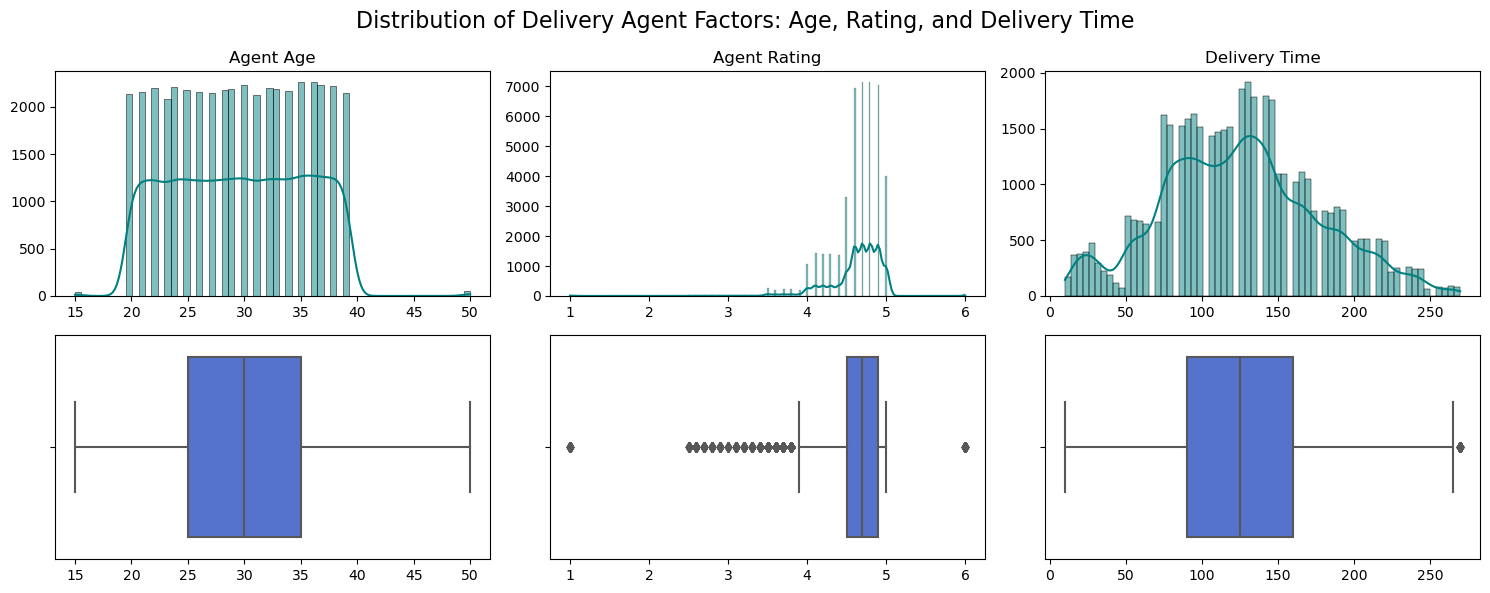

In [44]:
#define variable
delivery_agent_factors = ["Agent_Age", "Agent_Rating", "Delivery_Time"]

# create the subplots
fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(15, 6))

# loop through the variables and plot histograms and boxplots
for var_index, var_name in enumerate(delivery_agent_factors):
    row_index = 0  
    
    # plot histogram with KDE and custom color
    sns.histplot(df, x=var_name, kde=True, ax=axes[row_index][var_index], color='teal')  
    axes[row_index][var_index].set_ylabel("")
    axes[row_index][var_index].set_xlabel("")
    axes[row_index][var_index].set_title(var_name.replace('_', ' '))
    
    # plot boxplot with custom colour
    sns.boxplot(df, x=var_name, ax=axes[row_index + 1][var_index], color='royalblue')  
    axes[row_index + 1][var_index].set_ylabel("")
    axes[row_index + 1][var_index].set_xlabel("")

# add a title above all subplots
fig.suptitle("Distribution of Delivery Agent Factors: Age, Rating, and Delivery Time", fontsize=16)

# adjust layout
plt.tight_layout()
plt.show()

**Agent Age**→ The histogram illustrates that most delivery agents are between 25 and 40 years old, with fewer younger or older agents. The boxplot reveals the median age and the interquartile range where most agents fall, while outliers highlight agents with unusually low or high ages.

**Agent Rating**→ According to the histogram, most agents receive ratings above 4.5, indicating strong customer satisfaction. However, a few agents are rated below 3, suggesting areas for improvement. The boxplot displays the median rating, the typical rating range, and outliers representing agents with exceptionally low ratings.

**Delivery Time**→ The histogram shows that the majority of deliveries are completed within 100 to 120 minutes, with some deliveries extending beyond this time range. The boxplot highlights the median delivery time, the typical range, and outliers that represent instances of delayed deliveries, often caused by factors such as traffic or weather.

<div style="text-align:left; color:	lightseagreen; font-size:12px">
<h3>Question 1. What is the relationship between the agent’s age and delivery time?</h3>
</div>

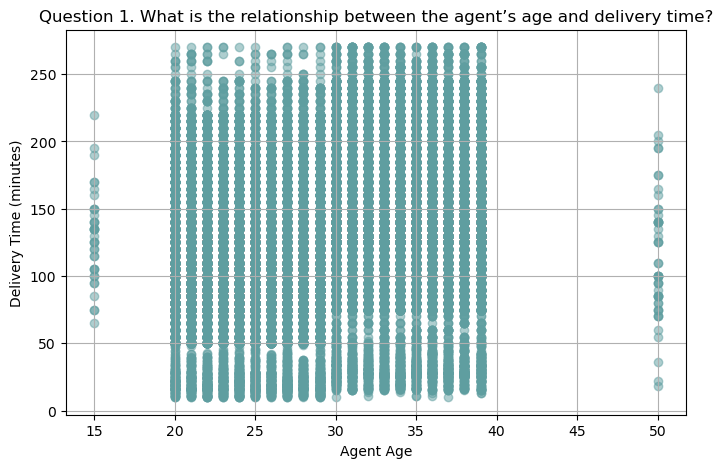

In [47]:
age_delivery_corr = df_cleaned['Agent_Age'].corr(df_cleaned['Delivery_Time'])

plt.figure(figsize=(8, 5))
plt.scatter(df_cleaned['Agent_Age'], df_cleaned['Delivery_Time'], alpha=0.5, color='cadetblue')
plt.title('Question 1. What is the relationship between the agent’s age and delivery time?')
plt.xlabel('Agent Age')
plt.ylabel('Delivery Time (minutes)')
plt.grid(True)
plt.show()

Result: 

The calculated correlation is 0.25, indicating a weak positive relationship.

Conclusion: The agent’s age does not significantly impact delivery performance. No optimization based on this factor is necessary.

<div style="text-align:left; color:	lightseagreen; font-size:12px">
<h3>Question 2. How does the agent’s rating influence delivery time?</h3>
</div>

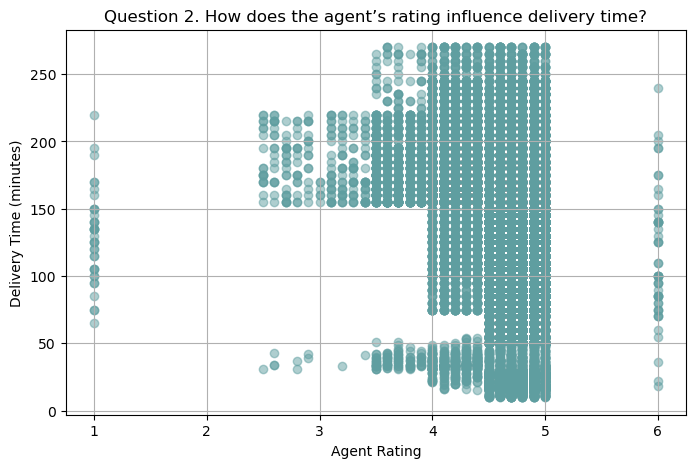

In [50]:
rating_delivery_corr = df['Agent_Rating'].corr(df['Delivery_Time'])

plt.figure(figsize=(8, 5))
plt.scatter(df['Agent_Rating'], df['Delivery_Time'], alpha=0.5, color='cadetblue')
plt.title('Question 2. How does the agent’s rating influence delivery time?')
plt.xlabel('Agent Rating')
plt.ylabel('Delivery Time (minutes)')
plt.grid(True)
plt.show()

Result:

The correlation is -0.29, indicating a moderate negative relationship.

Conclusion: Agents with higher ratings tend to deliver faster. Rating is a relevant factor for evaluating agent performance.

<div style="text-align:left; color:	lightseagreen; font-size:12px">
<h3>Question 3.  Which agents deliver the fastest, and what are their characteristics?
</h3>
</div>

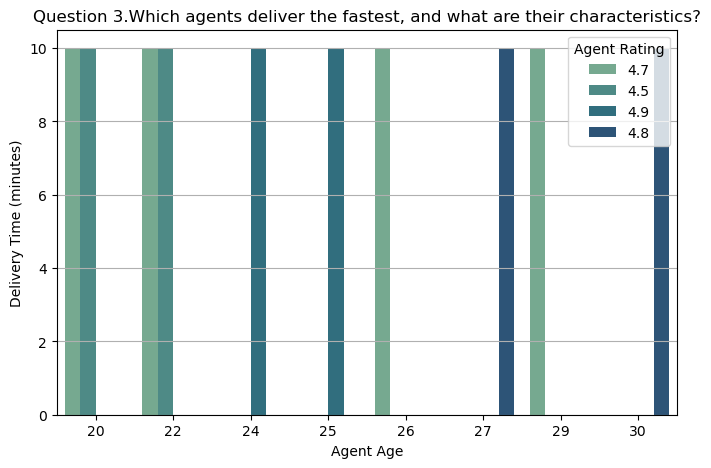

In [53]:
# select the top 10 fastest deliveries
top_fast_agents = df_cleaned.sort_values('Delivery_Time').head(10)[['Agent_Age', 'Agent_Rating', 'Delivery_Time']]

# sort the data by Agent_Age 
top_fast_agents_sorted = top_fast_agents.sort_values('Agent_Age')

# bar plot 
plt.figure(figsize=(8, 5))
sns.barplot(
    x=top_fast_agents_sorted['Agent_Age'].astype(str), 
    y=top_fast_agents_sorted['Delivery_Time'], 
    hue=top_fast_agents_sorted['Agent_Rating'].astype(str), 
    palette='crest' 
)
plt.title('Question 3.Which agents deliver the fastest, and what are their characteristics?')
plt.xlabel('Agent Age')
plt.ylabel('Delivery Time (minutes)')
plt.legend(title='Agent Rating')
plt.grid(True, axis='y')
plt.show()


Result:

Agents with the shortest delivery times have ages between 20 and 30 years and ratings between 4.5 and 4.9.

Conclusion: A high-performing agent profile includes high ratings, but this factor should be combined with other external factors.

<div style="text-align:left; color:	lightseagreen; font-size:12px">
<h3>Question 4.  Are there significant performance differences between agents with similar ratings but different ages?
</h3>
</div>


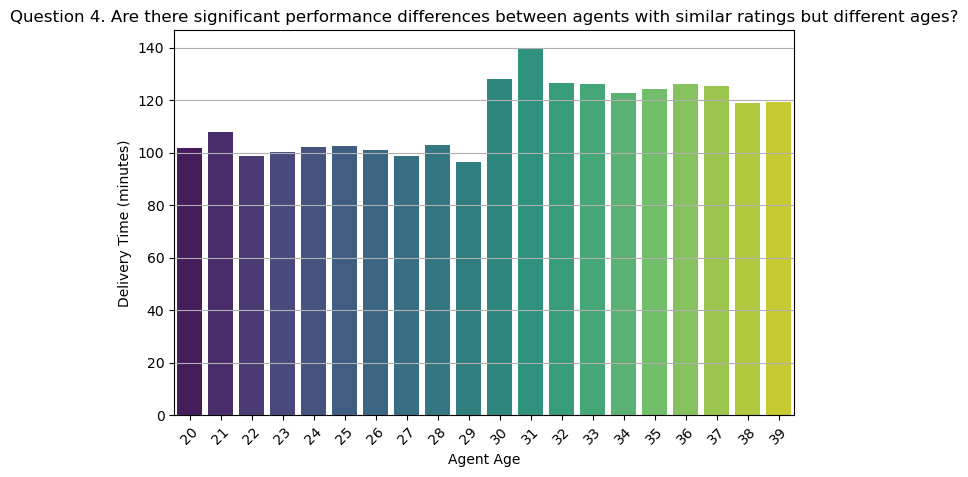

In [56]:
performance_by_rating_age = df_cleaned.groupby(['Agent_Rating', 'Agent_Age'])['Delivery_Time'].mean().reset_index()

rating_filter = performance_by_rating_age[performance_by_rating_age['Agent_Rating'] == 4.5]

plt.figure(figsize=(8, 5))
sns.barplot(x='Agent_Age', y='Delivery_Time', data=rating_filter, palette='viridis')
plt.title('Question 4. Are there significant performance differences between agents with similar ratings but different ages?')
plt.xlabel('Agent Age')
plt.ylabel('Delivery Time (minutes)')
plt.xticks(rotation=45)
plt.grid(True, axis='y')
plt.show()


Result:

There are significant variations in delivery time based on age, even for agents with the same rating.

Conclusion: External factors (traffic, weather conditions) may have a greater impact on performance than age.

<div style="text-align:left; color:	lightseagreen; font-size:12px">
<h3>Question 5.  ⁠Which time intervals have the highest average delivery times?</h3>
</div>

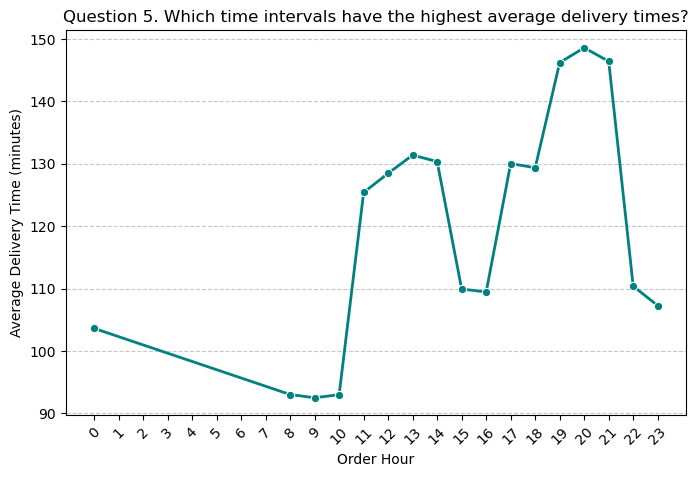

In [59]:
hourly_analysis = df_cleaned.groupby('Order_Hour')['Delivery_Time'].mean().reset_index()

# generate a line plot for better visualization of delivery time by hour
plt.figure(figsize=(8, 5))
sns.lineplot(x='Order_Hour', y='Delivery_Time', data=hourly_analysis, marker='o', color='teal', linewidth=2)
plt.title('Question 5. ⁠Which time intervals have the highest average delivery times?')
plt.xlabel('Order Hour')
plt.ylabel('Average Delivery Time (minutes)')
plt.xticks(range(0, 24), rotation=45)
plt.grid(True, axis='y', linestyle='--', alpha=0.7)
plt.show()



Result:

Delivery times are highest between 7 PM and 9 PM, peaking at 148 minutes.

Conclusion: Evening hours experience delays, likely due to increased traffic and order volumes.

<div style="text-align:left; color:	lightseagreen; font-size:12px">
<h3>Question 6.  On which days of the week are delivery times higher?</h3>
</div>

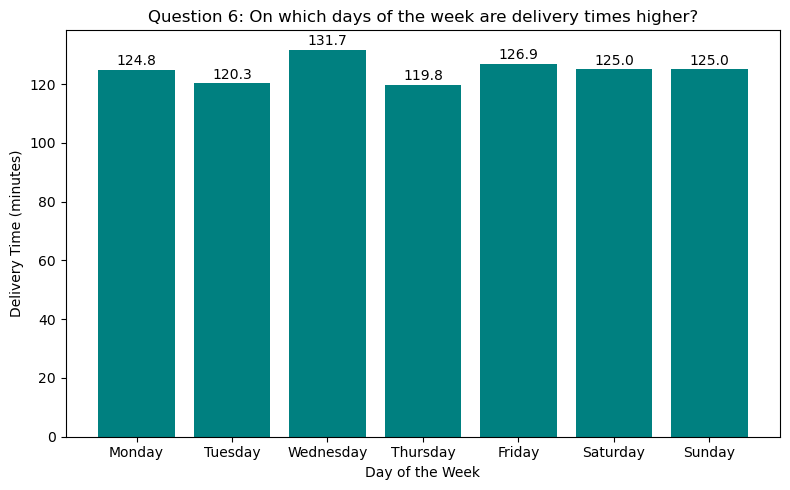

In [62]:
weekday_analysis = df_cleaned.groupby('Weekday')['Delivery_Time'].mean().reset_index()
weekday_analysis['Weekday'] = pd.Categorical(
    weekday_analysis['Weekday'],
    categories=[0, 1, 2, 3, 4, 5, 6],  # Monday to Sunday
    ordered=True
)

# round the values to 1 decimal place
weekday_analysis['Delivery_Time'] = weekday_analysis['Delivery_Time'].round(1)

# create the plot
plt.figure(figsize=(8, 5))
plt.bar(['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday'], 
        weekday_analysis['Delivery_Time'], color='teal')

# add titles and labels
plt.title('Question 6: On which days of the week are delivery times higher?')
plt.xlabel('Day of the Week')
plt.ylabel('Delivery Time (minutes)')

# add data labels on top of each bar
for i, v in enumerate(weekday_analysis['Delivery_Time']):
    plt.text(i, v + 0.5, str(v), ha='center', va='bottom', color='black')

plt.tight_layout()
plt.show()


Result:

The longest delivery times occur on Wednesdays (131 minutes) and Fridays (126 minutes).

Conclusion: Midweek and end-of-week deliveries may face more traffic and increased order volumes.

<div style="text-align:left; color:	lightseagreen; font-size:12px">
<h3>Question 7.  How does delivery performance vary across different geographic zones?</h3>
</div>

In [65]:
zone_analysis = df_cleaned.groupby('Area')['Delivery_Time'].mean().reset_index()


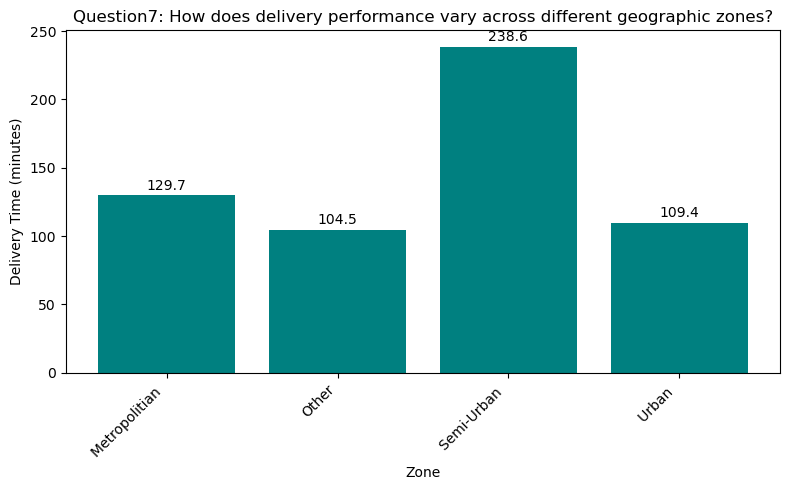

In [66]:
zone_analysis['Delivery_Time'] = zone_analysis['Delivery_Time'].round(1)

plt.figure(figsize=(8, 5))
plt.bar(zone_analysis['Area'], zone_analysis['Delivery_Time'], color='teal')

plt.title('Question7: How does delivery performance vary across different geographic zones?')
plt.xlabel('Zone')
plt.ylabel('Delivery Time (minutes)')
plt.xticks(rotation=45, ha='right')


for i, v in enumerate(zone_analysis['Delivery_Time']):
    plt.text(i, v + 2, str(v), ha='center', va='bottom', color='black')

plt.tight_layout()
plt.show()

Result:
Delivery times are longer in Semi-Urban areas


<div style="text-align:left; color:	lightseagreen; font-size:12px">
<h3>Question 8.  How do different weather conditions impact delivery times?</h3>
</div>

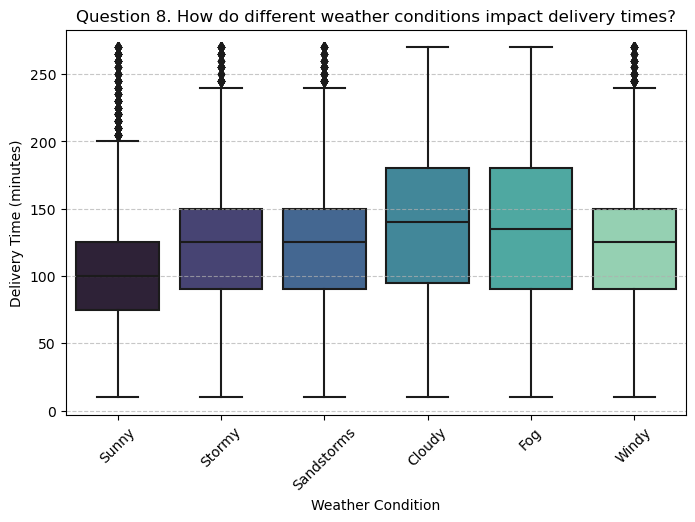

In [69]:
weather_analysis_time = df_cleaned.groupby('Weather')['Delivery_Time'].mean().reset_index()

plt.figure(figsize=(8, 5))
sns.boxplot(x='Weather', y='Delivery_Time', data=df_cleaned, palette='mako')
plt.title('Question 8. How do different weather conditions impact delivery times?')
plt.xlabel('Weather Condition')
plt.ylabel('Delivery Time (minutes)')
plt.xticks(rotation=45)
plt.grid(True, axis='y', linestyle='--', alpha=0.7)
plt.show()


Result:

Longest delivery times occur under cloudy (138 minutes) and foggy (136 minutes) conditions.

The shortest times are under sunny (103 minutes) weather.

Conclusion: Adverse weather conditions (fog, clouds) likely impact road visibility and traffic, leading to delays.


<div style="text-align:left; color:	lightseagreen; font-size:12px">
<h3>Question 9.  Which traffic conditions lead to the highest delivery times?</h3>
</div>

  Traffic  Delivery_Time
0    High     129.424115
1     Jam     147.758980
2     Low     101.354557
3  Medium     126.839669


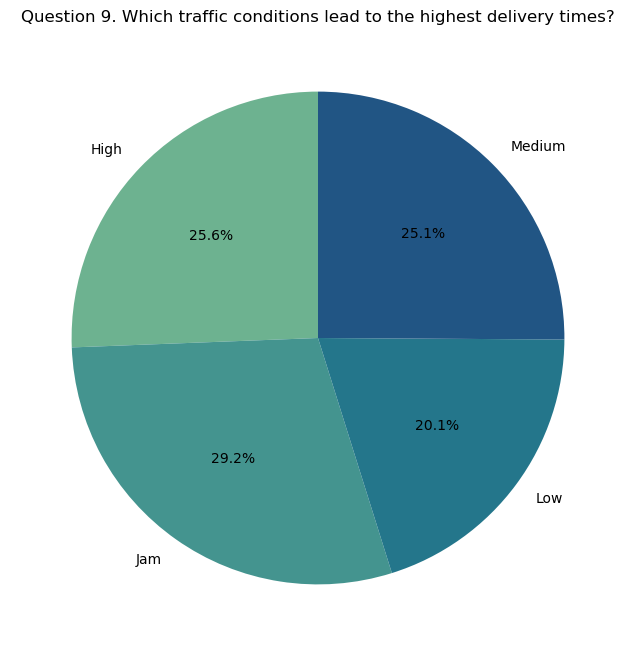

In [72]:
# unique values check
unique_values = df_cleaned['Traffic'].unique()
unique_values

# clean the 'Traffic' column
df_cleaned['Traffic'] = df_cleaned['Traffic'].str.strip()  # Remove leading and trailing whitespace
df_cleaned['Traffic'].replace('NaN', np.nan, inplace=True)  # Replace string 'NaN' with actual NaN

# recalculate traffic impact
df_cleaned = df_cleaned.dropna(subset=['Traffic'])
traffic_impact = df_cleaned.groupby('Traffic')['Delivery_Time'].mean().reset_index()

# display the cleaned traffic impact values
print(traffic_impact)

# plot the delivery times by traffic condition using a pie chart
plt.figure(figsize=(8, 8))
plt.pie(traffic_impact['Delivery_Time'], labels=traffic_impact['Traffic'],
        autopct='%1.1f%%', startangle=90, colors=sns.color_palette('crest', len(traffic_impact)))
plt.title('Question 9. Which traffic conditions lead to the highest delivery times?')
plt.show()

Result:
Delivery times are longest under traffic jam conditions, averaging 147.8 minutes, likely due to severe congestion and delays. High traffic also causes significant delays with an average of 129.4 minutes, while medium traffic leads to moderate delays, averaging 126.8 minutes. In contrast, low traffic conditions result in the shortest delivery time of 101.4 minutes, indicating minimal travel disruptions.


Conclusions:
The analysis demonstrates that delivery performance is influenced by multiple factors, including agent characteristics, time of day, geographic zones, traffic, and weather. 
To optimise last-mile operations, businesses should adopt a multi-faceted approach that includes improving agent performance, dynamic scheduling, predictive traffic management, and infrastructure enhancements. By implementing these strategies, organisations can enhance delivery efficiency, reduce delays, and provide a more reliable customer experience.

In [75]:
df_cleaned.to_csv("df_cleaned.csv", index=False)